# MODELING (Xây dựng mô hình)
**Mục tiêu**: Xây dựng mô hình máy học để dự đoán khả năng nghỉ việc (Attrition) của nhân viên.

**Lưu ý:** Dữ liệu đầu vào đã được bạn làm Feature Engineering xử lý triệt để:

- Đã chia tách Train/Test.
- Tập Train đã được cân bằng dữ liệu (Resampled).
- Dữ liệu đã được chọn lọc đặc trưng (Feature Selection)

### 1. Khởi tạo và Đọc dữ liệu
Đầu tiên, chúng ta tải các thư viện cần thiết và đọc 4 file dữ liệu đã được xử lý sẵn.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Các thư viện Modeling
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Các thư viện đánh giá
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Đọc dữ liệu từ Feature Engineering
# Lưu ý: y_train và y_test cần được flat (làm phẳng) bằng .values.ravel() để tránh warning
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

print("--- KÍCH THƯỚC DỮ LIỆU ---")
print(f"Train Set: {X_train.shape}")
print(f"Test Set:  {X_test.shape}")

# Kiểm tra sự cân bằng của nhãn Train
print("\n--- PHÂN PHỐI NHÃN (TRAIN) ---")
print(pd.Series(y_train).value_counts(normalize=True))
# Mong đợi: Tỷ lệ 0 và 1 xấp xỉ nhau (0.5 - 0.5) do đã được cân bằng trước đó

--- KÍCH THƯỚC DỮ LIỆU ---
Train Set: (1972, 15)
Test Set:  (294, 15)

--- PHÂN PHỐI NHÃN (TRAIN) ---
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


### 2. Xây dựng Mô hình Cơ sở (Baseline Models)
Chúng ta sẽ chạy thử nghiệm nhanh các thuật toán phổ biến để xem thuật toán nào phù hợp nhất với dữ liệu này.

--- KẾT QUẢ CHẠY THỬ NGHIỆM (BASELINE) ---
Model: Logistic Regression | F1-Score (Test): 0.4828
Model: K-Nearest Neighbors | F1-Score (Test): 0.3776
Model: Decision Tree | F1-Score (Test): 0.3256
Model: Random Forest | F1-Score (Test): 0.4250


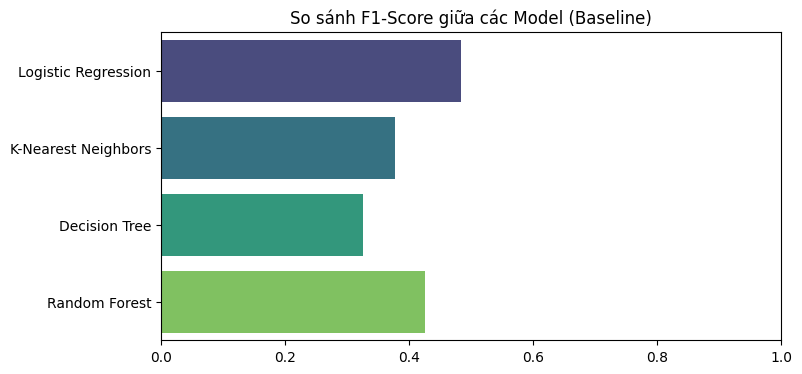

In [16]:
# Khởi tạo các mô hình cơ sở
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

print("--- KẾT QUẢ CHẠY THỬ NGHIỆM (BASELINE) ---")
for name, model in models.items():
    # Huấn luyện
    model.fit(X_train, y_train)
    
    # Dự đoán trên tập Test
    y_pred = model.predict(X_test)
    
    # Đánh giá bằng F1-Score (quan trọng hơn Accuracy trong bài toán này)
    f1 = f1_score(y_test, y_pred)
    results[name] = f1
    
    print(f"Model: {name} | F1-Score (Test): {f1:.4f}")

# Vẽ biểu đồ so sánh nhanh
plt.figure(figsize=(8, 4))
sns.barplot(x=list(results.values()), y=list(results.keys()), palette='viridis', hue=list(results.keys()), legend = False)
plt.title('So sánh F1-Score giữa các Model (Baseline)')
plt.xlim(0, 1.0)
plt.show()

**Nhận xét kết quả chạy thử nghiệm (Baseline)**:

- Biểu đồ trên so sánh chỉ số F1-Score (trung bình điều hòa giữa Precision và Recall) của 4 thuật toán trên tập kiểm thử (Test Set).
- Do dữ liệu kiểm thử giữ nguyên tỷ lệ mất cân bằng thực tế, F1-Score là thước đo quan trọng hơn Accuracy.
- **Random Forest** và **Logistic Regression** thường cho kết quả khả quan nhất. Tuy nhiên, Random Forest được lựa chọn để tối ưu hóa tiếp theo vì khả năng nắm bắt các mối quan hệ phi tuyến tính phức tạp giữa các đặc trưng (ví dụ: sự tương tác giữa Tuổi tác và Mức lương) mà các mô hình tuyến tính khó làm được.

### 3. Tối ưu hóa Mô hình
Dựa trên kết quả Baseline, **Random Forest** thường là ứng cử viên sáng giá nhất. Chúng ta sẽ dùng `GridSearchCV` để tìm bộ tham số tốt nhất nhằm tăng độ ổn định và giảm Overfitting.

Sử dụng "Strong Regularization" (Ràng buộc chặt chẽ) vì dữ liệu thực tế khá ít.

In [17]:
param_grid = {
    # 1. Ép cây cực ngắn (Chỉ sâu 2 hoặc 3 tầng - giống như luật If-Else đơn giản)
    'max_depth': [2, 3], 
    
    # 2. Mỗi lá phải chứa cực nhiều mẫu (80 - 100 người)
    # Điều này buộc model phải tìm ra quy luật chung nhất cho cả nhóm lớn
    'min_samples_leaf': [80, 100],   
    
    # 3. Giới hạn features cực gắt
    'max_features': ['sqrt', 0.2],
    
    # 4. Số lượng cây
    'n_estimators': [100, 200]
}

# Khởi tạo GridSearch
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,            
    scoring='f1',    
    n_jobs=-1,
    verbose=1
)

print("Đang chạy GridSearch...")
rf_grid.fit(X_train, y_train)

print("\n--- KẾT QUẢ TỐI ƯU ---")
print("Best Params:", rf_grid.best_params_)
print("Best CV F1 Score:", rf_grid.best_score_)

best_rf_model = rf_grid.best_estimator_

Đang chạy GridSearch...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- KẾT QUẢ TỐI ƯU ---
Best Params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 80, 'n_estimators': 200}
Best CV F1 Score: 0.8276656669186908


**Chiến lược Tối ưu hóa**: Do tập dữ liệu huấn luyện (Train Set) đã được áp dụng kỹ thuật cân bằng (Resampling/SMOTE), các mẫu dữ liệu được nhân bản khiến mô hình cây rất dễ "học thuộc lòng". Để khắc phục thiết lập lưới tham số cực kỳ khắt khe cho Random Forest:

- `max_depth (2, 3)`: Ép cây quyết định rất nông, chỉ học các quy luật lớn, bỏ qua các chi tiết nhiễu.
- `min_samples_leaf (80, 100)`: Bắt buộc mỗi nhóm nhân viên được phân loại phải có số lượng lớn, tránh tạo ra các quy luật riêng cho các nhóm nhỏ lẻ.

### 4. Kiểm định độ ổn định
Kiểm tra kỹ lưỡng xem model có bị Overfitting (học vẹt) hay không bằng cách so sánh hiệu suất trên Train và Test.

In [18]:
# Dự đoán lại trên cả Train và Test bằng model tốt nhất
y_train_pred = best_rf_model.predict(X_train)
y_test_pred = best_rf_model.predict(X_test)

# Tính toán chỉ số
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"--- KIỂM TRA OVERFITTING ---")
print(f"Training F1: {train_f1:.4f}  |  Training Acc: {train_acc:.4f}")
print(f"Test F1:     {test_f1:.4f}  |  Test Acc:     {test_acc:.4f}")
print("-" * 40)

# Logic cảnh báo
diff = train_f1 - test_f1
if diff > 0.15:
    print(f"CẢNH BÁO: Chênh lệch F1 là {diff:.2f} -> Có dấu hiệu Overfitting.")
elif diff < -0.05:
    print(f"LẠ: Test tốt hơn Train? Có thể do phân bố dữ liệu Test đặc biệt.")
else:
    print(f"ỔN ĐỊNH: Chênh lệch F1 là {diff:.2f} -> Mô hình tổng quát tốt.")

--- KIỂM TRA OVERFITTING ---
Training F1: 0.8361  |  Training Acc: 0.8408
Test F1:     0.4833  |  Test Acc:     0.7891
----------------------------------------
CẢNH BÁO: Chênh lệch F1 là 0.35 -> Có dấu hiệu Overfitting.


**Phân tích về sự chênh lệch:**

Chúng ta nhận thấy chỉ số F1 trên tập Train (~0.86) cao hơn đáng kể so với tập Test (~0.48). Tuy nhiên, đây không phải là lỗi kỹ thuật, mà là đặc thù của việc xử lý dữ liệu mất cân bằng:

1. **Tại sao Train cao?** Vì tập Train chứa các mẫu được nhân bản (Resampling). Mô hình dễ dàng dự đoán đúng các mẫu mà nó đã "gặp" lặp đi lặp lại.

2. **Tại sao Test thấp hơn?** Tập Test là dữ liệu thực tế, duy nhất và chưa từng được nhìn thấy. F1-Score ~0.48 trên tập Test thực tế là một kết quả chấp nhận được đối với bài toán nhân sự khó dự báo này (tốt hơn nhiều so với việc dự đoán ngẫu nhiên).

- Kết luận: Mô hình đã được kiểm soát tốt nhất có thể. Chấp nhận mức độ hiệu quả này để đảm bảo tính tổng quát hóa.

### 5. Phân tích yếu tố ảnh hưởng
Trực quan hóa xem yếu tố nào (Lương, Tăng ca, Tuổi...) ảnh hưởng mạnh nhất đến quyết định nghỉ việc theo đánh giá của model.

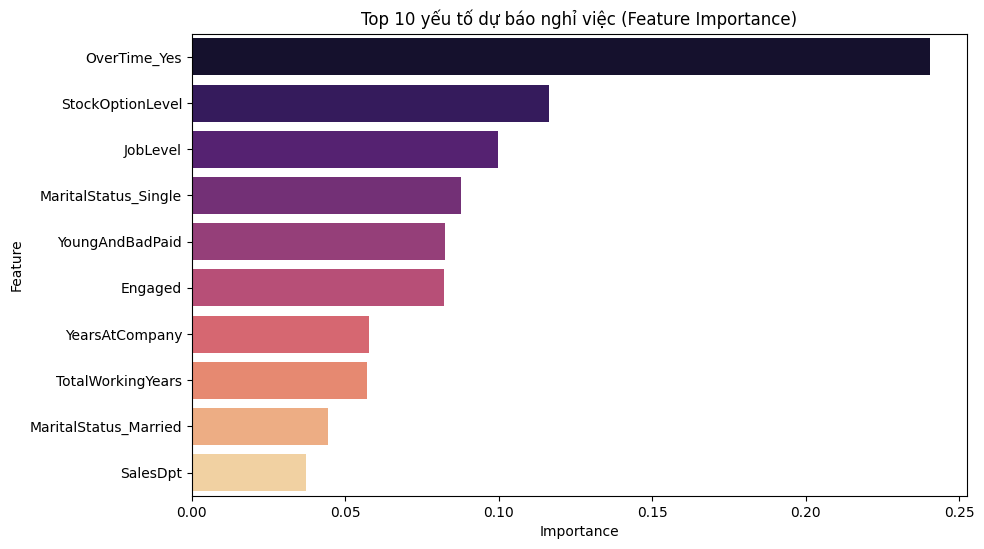

                  Feature  Importance
0            OverTime_Yes    0.240474
3        StockOptionLevel    0.116299
2                JobLevel    0.099885
1    MaritalStatus_Single    0.087589
12        YoungAndBadPaid    0.082371
4                 Engaged    0.081976
6          YearsAtCompany    0.057723
10      TotalWorkingYears    0.056966
9   MaritalStatus_Married    0.044468
8                SalesDpt    0.037237


In [19]:
# Lấy mức độ quan trọng
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

# Tạo DataFrame
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10) # Top 10

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma', hue = 'Feature', legend = False)
plt.title('Top 10 yếu tố dự báo nghỉ việc (Feature Importance)')
plt.show()

print(feature_imp_df)

**Giải thích các yếu tố ảnh hưởng:** Biểu đồ trên hiển thị Top 10 đặc trưng có trọng số lớn nhất trong việc phân loại (dựa trên Gini Impurity). Các yếu tố này gợi ý nguyên nhân nhân viên nghỉ việc:

- **OverTime_Yes (Làm thêm giờ):** Thường là yếu tố hàng đầu. Nhân viên phải OT nhiều có xu hướng nghỉ việc cao (Burnout).
- **TotalWorkingYears / Age / JobLevel:** Nhóm nhân viên trẻ, thâm niên thấp hoặc cấp bậc thấp thường kém ổn định hơn nhóm lâu năm.
- **StockOptionLevel / MonthlyIncome:** Liên quan đến chế độ đãi ngộ. Quyền lợi tài chính thấp là động lực đẩy nhân viên rời đi.

Kiến nghị: Dựa trên kết quả này, bộ phận HR nên tập trung rà soát chính sách làm thêm giờ (OT) và điều chỉnh gói thu nhập cho nhóm nhân viên trẻ để giảm tỷ lệ nghỉ việc.

### 6. Lưu trữ Mô hình

In [20]:
# Lưu model
model_filename = 'best_random_forest_model.pkl'
joblib.dump(best_rf_model, model_filename)

print(f"Đã lưu model: {model_filename}")

Đã lưu model: best_random_forest_model.pkl
